# Build the complete paired synthetic 80 m datasets

This notebook applies the transformation and locked calibration developed in `seadronessee_30m_to_80m_simulation_pilot.ipynb` to the complete **eligible** 25--35 m SeaDronesSee object split.

It creates two paired datasets:

1. **Geometry-only:** a wider real source footprint is reduced to 640×640 using Lanczos resampling.
2. **Calibrated:** the identical geometry is followed by the low-level effects selected using the real 80 m calibration and validation videos.

The calibrated training set is the primary source for the later synthetic-pair Procrustes experiment. Geometry-only remains a control for determining whether calibration adds value.

Objects that lack enough real pixels around them are excluded. The process never invents or pads missing background.

## Transformation flow

```text
25--35 m labelled object
        ↓ select the wider footprint expected at 80 m
        ↓ optional calibrated pre-resize optical effect
        ↓ Lanczos reduction to 640×640
        ↓ calibrated haze/noise/compression if enabled
paired synthetic 80 m image + transformed annotation
```

For a source recorded at altitude $\(h_s\)$, the approximate linear object scale is

$$s = \frac{h_s}{80}$$.

The source footprint side required for a 640×640 output is

$$L_s = \operatorname{round}\!\left(640\frac{80}{h_s}\right)$$.

This assumes unchanged camera intrinsics, an approximately planar sea surface, and a comparable viewing direction.

In [9]:
from pathlib import Path
import json
import os
import subprocess
import sys
from collections import Counter


def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "scripts" / "build_seadronessee_synthetic80.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root. Open this notebook from inside "
        "uav-altitude-feature-alignment."
    )


REPO_ROOT = find_repo_root()
# Keep Matplotlib's writable cache inside the repository's ignored local cache.
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".cache" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from IPython.display import display

BUILDER = REPO_ROOT / "scripts" / "build_seadronessee_synthetic80.py"
SOURCE_MANIFEST = REPO_ROOT / "data" / "splits" / "seadronessee" / "seadronessee_25_35m_object_split.csv"
CALIBRATION_CONFIG = REPO_ROOT / "results" / "seadronessee_30m_to_80m_pilot" / "calibrated_effects.json"
OUTPUT_ROOT = REPO_ROOT / "data" / "synthetic" / "seadronessee_30m_to_80m"
MANIFEST_ROOT = OUTPUT_ROOT / "manifests"

WORKERS = 4
OVERWRITE_EXISTING_IMAGES = True
VERIFY_EVERY_IMAGE = True

print("Repository:", REPO_ROOT)
print("Python kernel:", sys.executable)
print("Output:", OUTPUT_ROOT)

Repository: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment
Python kernel: c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\python.exe
Output: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\data\synthetic\seadronessee_30m_to_80m


## 1. Inspect the locked calibration

The builder reads the accepted calibration directly from the pilot result. This prevents manually copying values and accidentally generating a dataset with parameters different from those that passed validation.

A parameter set to `None` is disabled. With the present calibration, the additional effect is deliberately modest: the validation experiment selected a quality-95 JPEG round trip and did not justify extra blur, haze, or sensor noise.

In [10]:
calibration_document = json.loads(CALIBRATION_CONFIG.read_text(encoding="utf-8"))
assert calibration_document.get("accepted", False), "The calibration has not been accepted."

locked_effects = calibration_document["effects_for_dataset"]
print("Calibration videos:", calibration_document["calibration_videos"])
print("Validation videos:", calibration_document["validation_videos"])
print("Reserved real-80 m test videos:", calibration_document["heldout_test_videos_not_opened"])
print("Locked effects:")
print(json.dumps(locked_effects, indent=2))

Calibration videos: ['NorthSea_Thu_DJI_0107.MP4', 'NorthSea_Sat_DJI_0129.MP4']
Validation videos: ['NorthSea_Sat_DJI_0131.MP4']
Reserved real-80 m test videos: ['DJI_0064.MP4', 'DJI_0065.MP4']
Locked effects:
{
  "extra_psf_sigma_output_px": 0.0,
  "visibility_m": null,
  "airlight_srgb": [
    0.78,
    0.84,
    0.9
  ],
  "peak_electrons": null,
  "read_noise_electrons": 2.0,
  "jpeg_quality": 95
}


## 2. Audit eligibility without generating images

The dry run checks every labelled source object and reports whether the wider 80 m footprint is fully available inside its source frame. Excluded rows are written to an audit manifest with a reason.

This exclusion is scientifically preferable to filling missing regions with reflection, constant colour, generative imagery, or other artificial background.

In [11]:
def run_builder(*extra_arguments):
    command = [
        sys.executable,
        str(BUILDER),
        "--repo-root", str(REPO_ROOT),
        "--workers", str(WORKERS),
        *map(str, extra_arguments),
    ]
    completed = subprocess.run(command, capture_output=True, text=True)
    if completed.stdout.strip():
        print(completed.stdout.strip())
    if completed.returncode != 0:
        print(completed.stderr)
        raise RuntimeError(f"Dataset builder failed with exit code {completed.returncode}.")
    return completed


dry_run = run_builder("--dry-run")

Source objects:  3,307
Eligible pairs:  1,465
Excluded:        1,842
Dry run complete; no images were generated.


## 3. Generate both datasets

Running this cell creates the following folders:

```text
data/synthetic/seadronessee_30m_to_80m/
├── geometry_only/{train,val,test}/
├── calibrated/{train,val,test}/
├── manifests/paired_manifest.csv
├── manifests/excluded_manifest.csv
├── manifests/build_summary.json
└── README.md
```

`OVERWRITE_EXISTING_IMAGES = False` makes reruns resumable. Change it to `True` only when you intentionally want to regenerate every image after changing the method or calibration.

In [12]:
arguments = []
if OVERWRITE_EXISTING_IMAGES:
    arguments.append("--overwrite")

build_result = run_builder(*arguments)

Exception in thread Thread-12 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\ADMIN\AppData\Roaming\Python\Python310\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1499, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 330: character maps to <undefined>


Source objects:  3,307
Eligible pairs:  1,465
Excluded:        1,842
{
  "source_objects": 3307,
  "paired_objects": 1465,
  "excluded_objects": 1842,
  "target_altitude_m": 80.0,
  "output_side_px": 640,
  "geometry_files": 1465,
  "calibrated_files": 1465,
  "calibration_config_sha256": "8fe6c319c145bfe6c41b4bd884be5417741d8218678ea8dfc0735cca6b82988f",
  "calibrated_effects": {
    "extra_psf_sigma_output_px": 0.0,
    "visibility_m": null,
    "airlight_srgb": [
      0.78,
      0.84,
      0.9
    ],
    "peak_electrons": null,
    "read_noise_electrons": 2.0,
    "jpeg_quality": 95
  },
  "counts_by_split": {
    "test": 275,
    "train": 1010,
    "val": 180
  },
  "counts_by_class": {
    "boat": 182,
    "buoy": 54,
    "jetski": 34,
    "swimmer": 1195
  },
  "exclusions_by_reason": {
    "required_80m_footprint_outside_source_frame": 1842
  }
}
Dataset written to: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\data\synthetic\seadronessee_30m_to_80m


## 4. Inspect the generated manifests

`paired_manifest.csv` is the authoritative link between:

- the real source object and annotation;
- the geometry-only image;
- the calibrated image;
- the original and transformed bounding boxes;
- the train, validation, or test assignment;
- the calibration-configuration fingerprint.

Use `pair_id` to join features from the real 30 m and synthetic 80 m views.

In [13]:
summary = json.loads((MANIFEST_ROOT / "build_summary.json").read_text(encoding="utf-8"))
pairs = pd.read_csv(MANIFEST_ROOT / "paired_manifest.csv")
excluded = pd.read_csv(MANIFEST_ROOT / "excluded_manifest.csv")

print(json.dumps(summary, indent=2))
print("\nPaired counts by split and class:")
display(pairs.groupby(["split", "category_name"]).size().unstack(fill_value=0))

print("Exclusions by reason:")
display(excluded["exclusion_reason"].value_counts().rename_axis("reason").to_frame("objects"))

print("Example paired records:")
display(
    pairs[[
        "pair_id", "split", "category_name", "altitude_m",
        "actual_linear_scale", "geometry_image_path", "calibrated_image_path",
    ]].head()
)

{
  "source_objects": 3307,
  "paired_objects": 1465,
  "excluded_objects": 1842,
  "target_altitude_m": 80.0,
  "output_side_px": 640,
  "geometry_files": 1465,
  "calibrated_files": 1465,
  "calibration_config_sha256": "8fe6c319c145bfe6c41b4bd884be5417741d8218678ea8dfc0735cca6b82988f",
  "calibrated_effects": {
    "extra_psf_sigma_output_px": 0.0,
    "visibility_m": null,
    "airlight_srgb": [
      0.78,
      0.84,
      0.9
    ],
    "peak_electrons": null,
    "read_noise_electrons": 2.0,
    "jpeg_quality": 95
  },
  "counts_by_split": {
    "test": 275,
    "train": 1010,
    "val": 180
  },
  "counts_by_class": {
    "boat": 182,
    "buoy": 54,
    "jetski": 34,
    "swimmer": 1195
  },
  "exclusions_by_reason": {
    "required_80m_footprint_outside_source_frame": 1842
  }
}

Paired counts by split and class:


category_name,boat,buoy,jetski,swimmer
split,,,,
test,37,2,9,227
train,126,49,9,826
val,19,3,16,142


Exclusions by reason:


,objects
reason,
required_80m_footprint_outside_source_frame,1842


Example paired records:


,pair_id,split,category_name,altitude_m,actual_linear_scale,geometry_image_path,calibrated_image_path
0,train_00023853,train,buoy,25.398761,0.31746,data/synthetic/seadronessee_30m_to_80m/geometr...,data/synthetic/seadronessee_30m_to_80m/calibra...
1,train_00036480,train,buoy,33.698357,0.42133,data/synthetic/seadronessee_30m_to_80m/geometr...,data/synthetic/seadronessee_30m_to_80m/calibra...
2,train_00036483,train,swimmer,33.698357,0.42133,data/synthetic/seadronessee_30m_to_80m/geometr...,data/synthetic/seadronessee_30m_to_80m/calibra...
3,train_00036484,train,swimmer,33.698357,0.42133,data/synthetic/seadronessee_30m_to_80m/geometr...,data/synthetic/seadronessee_30m_to_80m/calibra...
4,train_00036485,train,swimmer,33.698357,0.42133,data/synthetic/seadronessee_30m_to_80m/geometr...,data/synthetic/seadronessee_30m_to_80m/calibra...


## 5. Verify the files

This check confirms that identifiers are unique, annotations remain inside the 640×640 output, paths exist, and every image can be decoded as RGB at the expected resolution. Full verification takes longer but is recommended after the first build.

In [14]:
assert pairs["pair_id"].is_unique
assert set(pairs["split"]) == {"train", "val", "test"}
assert (pairs["synthetic_bbox_x"] >= 0).all()
assert (pairs["synthetic_bbox_y"] >= 0).all()
assert ((pairs["synthetic_bbox_x"] + pairs["synthetic_bbox_width"]) <= 640.000001).all()
assert ((pairs["synthetic_bbox_y"] + pairs["synthetic_bbox_height"]) <= 640.000001).all()

all_paths = (
    [REPO_ROOT / path for path in pairs["geometry_image_path"]]
    + [REPO_ROOT / path for path in pairs["calibrated_image_path"]]
)
assert all(path.is_file() for path in all_paths)

paths_to_check = all_paths if VERIFY_EVERY_IMAGE else all_paths[:20]
dimensions = Counter()
modes = Counter()
for path in paths_to_check:
    with Image.open(path) as image:
        dimensions[image.size] += 1
        modes[image.mode] += 1
        image.verify()

assert set(dimensions) == {(640, 640)}
assert set(modes) == {"RGB"}
print(f"Verified {len(paths_to_check):,} images.")
print("Dimensions:", dict(dimensions))
print("Modes:", dict(modes))

Verified 2,930 images.
Dimensions: {(640, 640): 2930}
Modes: {'RGB': 2930}


## 6. Compare representative objects

The green box is the transformed object annotation. The geometry-only and calibrated columns use exactly the same source footprint and pair identifier. Their only difference is the locked calibrated image-formation step.

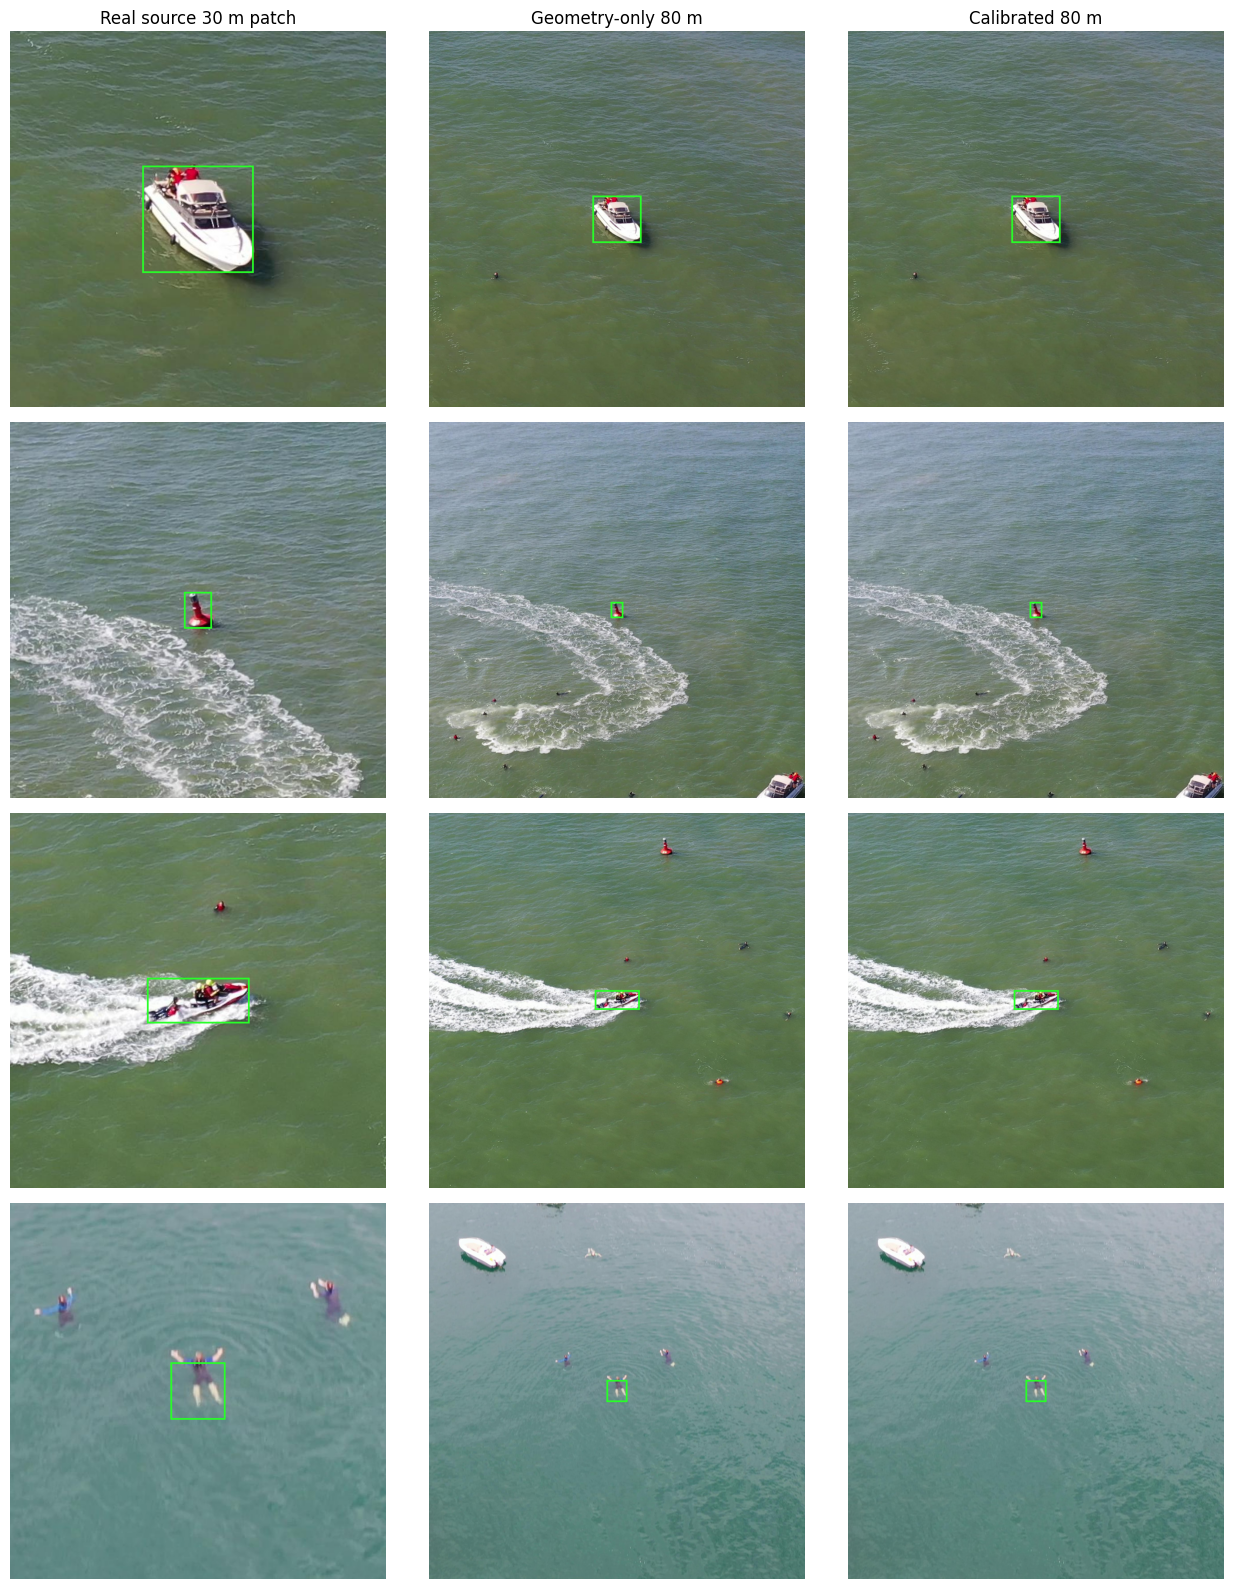

In [15]:
def draw_box(image, bbox, colour=(40, 255, 40)):
    output = image.copy()
    draw = ImageDraw.Draw(output)
    x, y, width, height = map(float, bbox)
    draw.rectangle((x, y, x + width, y + height), outline=colour, width=3)
    return output


# Choose a clearly visible held-out example from each class for inspection.
examples = (
    pairs[pairs["split"] == "test"]
    .sort_values("synthetic_bbox_area", ascending=False)
    .groupby("category_name", as_index=False)
    .head(1)
    .sort_values("category_name")
)

fig, axes = plt.subplots(len(examples), 3, figsize=(13, 4 * len(examples)))
column_titles = ["Real source 30 m patch", "Geometry-only 80 m", "Calibrated 80 m"]
for axis, title in zip(axes[0], column_titles):
    axis.set_title(title)

for row_index, (_, row) in enumerate(examples.iterrows()):
    with Image.open(REPO_ROOT / row["image_path"]) as opened:
        source = opened.convert("RGB")

    center_x = float(row["bbox_x"] + row["bbox_width"] / 2)
    center_y = float(row["bbox_y"] + row["bbox_height"] / 2)
    left = int(round(center_x - 320))
    top = int(round(center_y - 320))
    source_patch = source.crop((left, top, left + 640, top + 640))
    source_bbox = (
        float(row["bbox_x"] - left), float(row["bbox_y"] - top),
        float(row["bbox_width"]), float(row["bbox_height"]),
    )

    with Image.open(REPO_ROOT / row["geometry_image_path"]) as opened:
        geometry = opened.convert("RGB")
    with Image.open(REPO_ROOT / row["calibrated_image_path"]) as opened:
        calibrated = opened.convert("RGB")

    synthetic_bbox = (
        row["synthetic_bbox_x"], row["synthetic_bbox_y"],
        row["synthetic_bbox_width"], row["synthetic_bbox_height"],
    )
    panels = [
        draw_box(source_patch, source_bbox),
        draw_box(geometry, synthetic_bbox),
        draw_box(calibrated, synthetic_bbox),
    ]

    for column_index, panel in enumerate(panels):
        axes[row_index, column_index].imshow(panel)
        axes[row_index, column_index].axis("off")
    axes[row_index, 0].set_ylabel(str(row["category_name"]), fontsize=12)

plt.tight_layout()
plt.show()

## 7. Prepare the primary Procrustes input

Use only calibrated **training** pairs when fitting the primary synthetic Procrustes matrix. The actual feature extraction will be performed in the later Procrustes notebook using the same frozen encoder as the 30 m baseline.

```text
real 30 m member of pair ── frozen encoder ──► z_30
                                                ▲
                                                │ fit R on training pairs
                                                │
calibrated synthetic 80 m ─ frozen encoder ──► z_syn80
```

Validation pairs are for selecting preprocessing and mapping choices. Test pairs are for final synthetic held-out evaluation. Genuine 80 m videos remain the final external test and must not be used to fit the mapping.

In [16]:
procrustes_train_pairs = pairs[pairs["split"] == "train"].copy()
geometry_control_train_pairs = procrustes_train_pairs.copy()

print(f"Primary calibrated Procrustes training pairs: {len(procrustes_train_pairs):,}")
print(f"Validation pairs kept out of fitting: {(pairs['split'] == 'val').sum():,}")
print(f"Synthetic test pairs kept out of fitting: {(pairs['split'] == 'test').sum():,}")

display(
    procrustes_train_pairs[[
        "pair_id", "category_name", "image_path", "bbox_x", "bbox_y",
        "bbox_width", "bbox_height", "calibrated_image_path",
    ]].head()
)

Primary calibrated Procrustes training pairs: 1,010
Validation pairs kept out of fitting: 180
Synthetic test pairs kept out of fitting: 275


,pair_id,category_name,image_path,bbox_x,bbox_y,bbox_width,bbox_height,calibrated_image_path
0,train_00023853,buoy,data/raw/seadronessee/odv2/images/train/4863.jpg,1238.0,940.0,136.0,148.0,data/synthetic/seadronessee_30m_to_80m/calibra...
1,train_00036480,buoy,data/raw/seadronessee/odv2/images/train/6551.jpg,1492.0,904.0,50.0,72.0,data/synthetic/seadronessee_30m_to_80m/calibra...
2,train_00036483,swimmer,data/raw/seadronessee/odv2/images/train/6551.jpg,2533.0,807.0,18.0,13.0,data/synthetic/seadronessee_30m_to_80m/calibra...
3,train_00036484,swimmer,data/raw/seadronessee/odv2/images/train/6551.jpg,2601.0,830.0,41.0,22.0,data/synthetic/seadronessee_30m_to_80m/calibra...
4,train_00036485,swimmer,data/raw/seadronessee/odv2/images/train/6551.jpg,2404.0,814.0,34.0,21.0,data/synthetic/seadronessee_30m_to_80m/calibra...


## Reporting rule

Report that the generated dataset contains only objects for which the full wider footprint was available. This selection favours objects away from image boundaries and is therefore not random.

The calibrated images are a **calibration-assisted controlled approximation** of SeaDronesSee at 80 m. They should not be described as perfect or universally photorealistic 80 m observations. Performance on untouched genuine 80 m videos remains the decisive evaluation.